In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

In [19]:
data = pd.read_csv("clean_housing.csv")
data.columns

Index(['MyUnknownColumn', 'crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age',
       'dis', 'rad', 'tax', 'ptratio', 'black', 'lstat', 'medv'],
      dtype='object')

In [20]:
data = data.drop(["MyUnknownColumn"], axis=1, errors="ignore")
X = data.drop("medv", axis=1)   # house features
y = data["medv"]

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [22]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [23]:
y_pred = model.predict(X_test)

In [24]:
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 2.64199108164885
R2 Score: 0.7639490409375259


In [25]:
new_house = [[0.02,18,2.31,0,0.53,6.5,65,4,1,296,15.3,396,4.98]]
price = model.predict(new_house)

print("Predicted Price:", price[0])

Predicted Price: 29.279678565548505


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


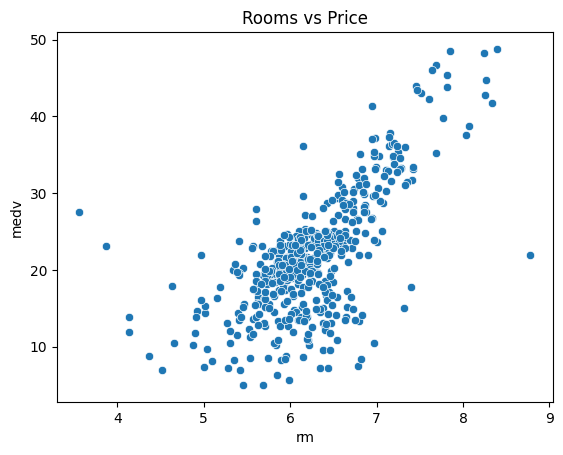

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(x="rm", y="medv", data=data)
plt.title("Rooms vs Price")
plt.show()

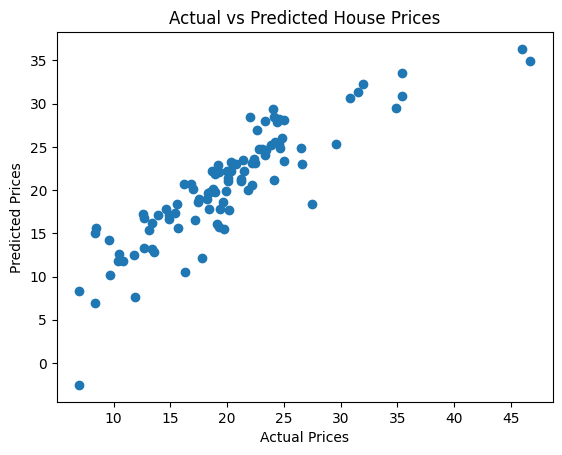

In [27]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")
plt.show()

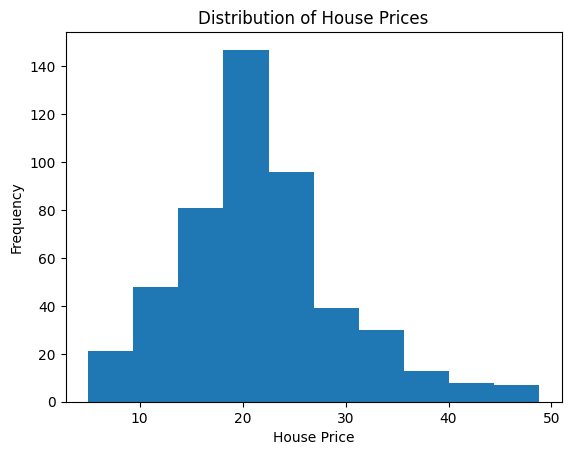

In [28]:
plt.hist(data["medv"])
plt.xlabel("House Price")
plt.ylabel("Frequency")
plt.title("Distribution of House Prices")
plt.show()

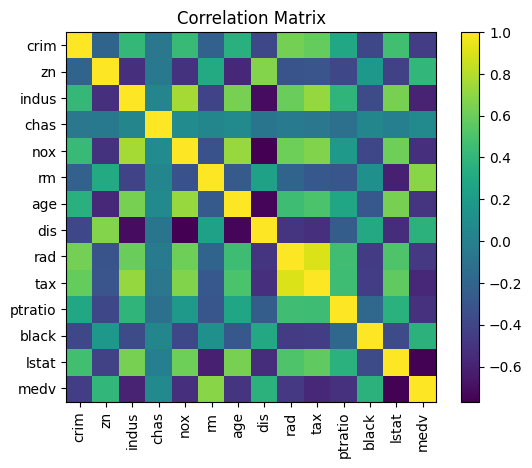

In [29]:
import numpy as np

corr = data.corr()

plt.imshow(corr)
plt.colorbar()
plt.title("Correlation Matrix")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.show()